# Stroke Rasterization: Curves, Brushes, and Anti-Aliased Marks  

## Overview

Rasterization maps vector geometry onto a discrete pixel grid. Lines, circles, and curves are defined in continuous coordinates, so a renderer must convert them to pixels before display.

In `prism`, the mark-making layer in `paint/brush.py` holds the rasterization kernels, the brush model, and the routines that sweep a brush along a path to form a stroke.

Two ideas anchor the brush model: incremental rasterization and brush-based painterly rendering. `_accumulate_line` steps along a line one pixel at a time, choosing each pixel from the sign of an error term updated by addition alone — the method of Bresenham, extended to curves by Zingl. `_accumulate_disc` fills a circular tip from the implicit-circle form. `create_brush` builds a bristle bundle, and `_deposit_bristles` sweeps it, sampling a quadratic Bézier per bristle and rasterizing each with the line kernel.

Aliasing shows most along slanted edges, where hard pixel decisions produce a staircase. Anti-aliasing instead sets boundary pixels by coverage, and the eye reads the gradation as a straight edge. The sections below move from primitive kernels to brush construction to the stroke-rendering functions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def style_panel(ax, face=None):
    ax.set_xticks([])
    ax.set_yticks([])
    if face is not None:
        ax.set_facecolor(face)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor("0.82")


def crop(img, pad=12, threshold=1e-6):
    ys, xs = np.where(img > threshold)
    if len(xs) == 0:
        h, w = img.shape
        return 0, w, h, 0
    return (
        max(int(xs.min()) - pad, 0),
        min(int(xs.max()) + pad, img.shape[1] - 1),
        min(int(ys.max()) + pad, img.shape[0] - 1),
        max(int(ys.min()) - pad, 0),
    )

## Foundations of Curve Rasterization

### The Rasterization Problem: Continuous Curves on a Discrete Grid

A line segment is specified by two endpoints, but it denotes a continuous set of points between them. A display, by contrast, is a finite grid of pixels at integer coordinates. Rasterizing the segment therefore means selecting a subset of pixels whose arrangement is perceived as the underlying continuous line. That selection is inherently approximate: a segment from $(0,0)$ to $(5,2)$ passes through pixel interiors, not through pixel centers in any exact one-to-one way.

The most direct construction uses the line equation itself. For a segment from $(x_0, y_0)$ to $(x_1, y_1)$ with slope between zero and one, the exact row at each integer column $x$ is

$$y = y_0 + \frac{y_1 - y_0}{x_1 - x_0}(x - x_0).$$

One may step across the columns, evaluate $y$, and round to the nearest integer to choose one pixel per column. This method is straightforward, but it is computationally wasteful. Each step requires a fractional slope and a multiplication, and each rounded value discards information that must be recomputed at the next column.

A second difficulty is geometric. Choosing one pixel per column works only when the line rises by less than one row per column. For steeper lines, adjacent columns may map to rows that are too far apart, producing visible gaps. A separate formulation that steps in $y$ instead of $x$ is then required, and a complete rasterizer must switch between such cases according to the octant.

The key reformulation begins by expressing the line implicitly, as a function that is zero on the line, positive on one side, and negative on the other:

$$f(x, y) = (y_1 - y_0)(x - x_0) - (x_1 - x_0)(y - y_0).$$

The sign of $f$ determines which side of the line a point lies on, and its magnitude increases with distance from the line. This perspective replaces repeated evaluation of the line height with a sign test that can be updated incrementally. The rasterizer can then choose between neighboring pixels using integer arithmetic alone.

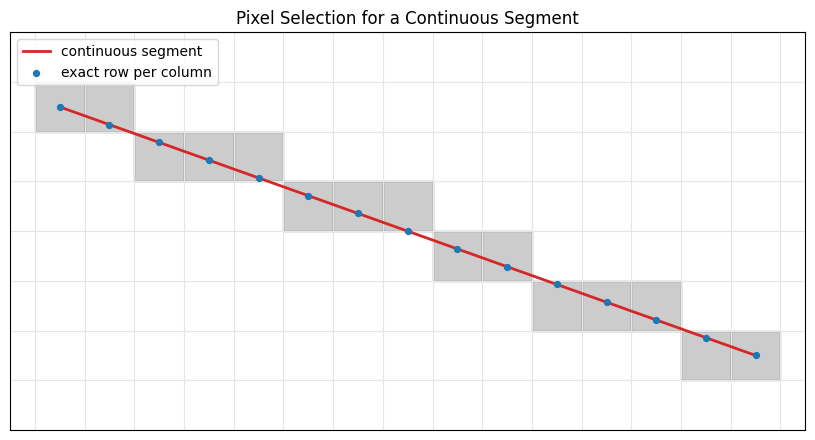

In [2]:
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

# the rasterization problem: which pixels approximate a continuous segment
p0 = np.array([0.0, 0.0])
p1 = np.array([14.0, 5.0])

# exact row per column, then round
xs = np.arange(int(p0[0]), int(p1[0]) + 1)
slope = (p1[1] - p0[1]) / (p1[0] - p0[0])
ys_exact = p0[1] + slope * (xs - p0[0])
ys_pixel = np.round(ys_exact).astype(int)

fig, ax = plt.subplots(figsize=(11, 4.5))

# pixel grid
for gx in range(-1, 16):
    ax.axvline(gx - 0.5, color="0.9", lw=0.8)
for gy in range(-2, 8):
    ax.axhline(gy - 0.5, color="0.9", lw=0.8)

# chosen pixels
ax.add_collection(
    PatchCollection(
        [Rectangle((x - 0.5, y - 0.5), 1, 1) for x, y in zip(xs, ys_pixel)],
        facecolor="0.8", edgecolor="0.55",
    )
)

# the continuous segment + its exact per-column samples
ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color="C3", lw=2, label="continuous segment")
ax.scatter(xs, ys_exact, s=18, color="C0", zorder=3, label="exact row per column")

ax.set_xlim(-1, 15)
ax.set_ylim(-1.5, 6.5)
ax.set_aspect("equal")
ax.invert_yaxis()
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="upper left")
ax.set_title("Pixel Selection for a Continuous Segment")
fig.tight_layout()
plt.show()

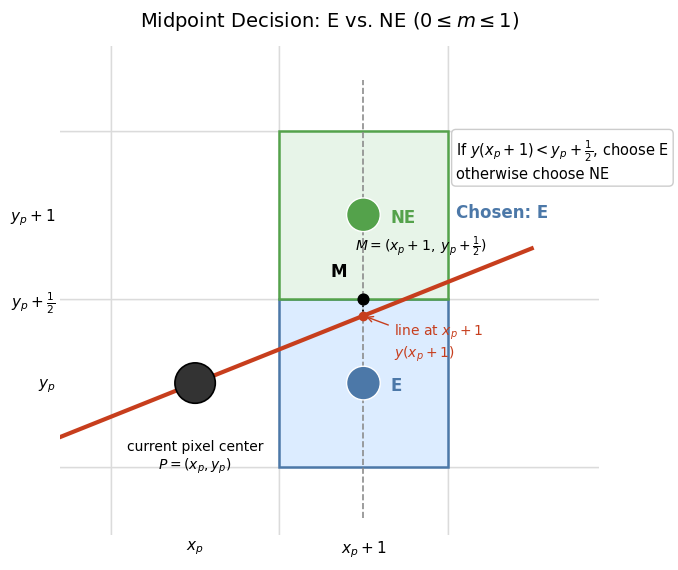

In [3]:
from matplotlib.patches import Rectangle, Circle

# example setup: slope in the 0 <= m <= 1 case
xp, yp = 0, 0
m = 0.4
xe = xp + 1

def y_line(x):
    return yp + m * (x - xp)

# key geometric points
P = (xp, yp)                          # current pixel center
M = (xp + 1, yp + 0.5)               # midpoint test location
Y = (xp + 1, y_line(xp + 1))         # line value at x_p + 1

choose_E = Y[1] < M[1]

fig, ax = plt.subplots(figsize=(8.4, 5.8))

# background grid
for cx in range(xp - 1, xp + 3):
    for cy in range(yp - 1, yp + 3):
        ax.add_patch(
            Rectangle(
                (cx - 0.5, cy - 0.5), 1, 1,
                facecolor="white",
                edgecolor="0.86",
                lw=1.0,
                zorder=0
            )
        )

# candidate pixels at x_p + 1
ax.add_patch(
    Rectangle(
        (xp + 1 - 0.5, yp - 0.5), 1, 1,
        facecolor="#dcecff", edgecolor="#4c78a8", lw=1.8, zorder=0.5
    )
)
ax.add_patch(
    Rectangle(
        (xp + 1 - 0.5, yp + 1 - 0.5), 1, 1,
        facecolor="#e7f4e8", edgecolor="#54a24b", lw=1.8, zorder=0.5
    )
)

# continuous line
xs = np.linspace(xp - 0.8, xp + 2.0, 300)
ax.plot(xs, y_line(xs), color="#c73e1d", lw=3.0, zorder=2)

# vertical guide at x_p + 1
ax.plot([xp + 1, xp + 1], [yp - 0.8, yp + 1.8],
        ls="--", lw=1.2, color="0.55", zorder=1)

# current pixel center p
ax.add_patch(Circle(P, 0.12, facecolor="0.2", edgecolor="black", lw=1.2, zorder=4))
ax.text(P[0], P[1] - 0.34, "current pixel center\n$P=(x_p, y_p)$",
        ha="center", va="top", fontsize=10)

# candidate centers e and ne
E = (xp + 1, yp)
NE = (xp + 1, yp + 1)

ax.add_patch(Circle(E, 0.10, facecolor="#4c78a8", edgecolor="white", lw=1.0, zorder=4))
ax.add_patch(Circle(NE, 0.10, facecolor="#54a24b", edgecolor="white", lw=1.0, zorder=4))

ax.text(E[0] + 0.16, E[1] - 0.02, "E", color="#4c78a8",
        fontsize=12, fontweight="bold", va="center")
ax.text(NE[0] + 0.16, NE[1] - 0.02, "NE", color="#54a24b",
        fontsize=12, fontweight="bold", va="center")

# midpoint m
ax.scatter([M[0]], [M[1]], s=60, color="black", zorder=5)
ax.text(M[0] - 0.10, M[1] + 0.13, "M", fontsize=12, fontweight="bold", ha="right")
ax.text(M[0] - 0.05, M[1] + 0.28, r"$M=(x_p+1,\; y_p+\frac{1}{2})$",
        fontsize=10, ha="left")

# line value at x_p + 1
ax.scatter([Y[0]], [Y[1]], s=36, color="#c73e1d", zorder=5)
ax.plot([Y[0], Y[0]], [Y[1], M[1]], color="black", lw=1.2, ls=":", zorder=3)
ax.annotate(
    r"line at $x_p+1$" + "\n" + r"$y(x_p+1)$",
    xy=Y, xytext=(xp + 1.18, Y[1] - 0.25),
    fontsize=10, color="#c73e1d",
    arrowprops=dict(arrowstyle="->", color="#c73e1d", lw=1.0)
)

# decision text
rule_text = (
    r"If $y(x_p+1) < y_p+\frac{1}{2}$, choose E"
    "\n"
    r"otherwise choose NE"
)
ax.text(
    xp + 1.55, yp + 1.45,
    rule_text,
    fontsize=10.5,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.8")
)

chosen_label = "Chosen: E" if choose_E else "Chosen: NE"
chosen_color = "#4c78a8" if choose_E else "#54a24b"
ax.text(
    xp + 1.55, yp + 0.98,
    chosen_label,
    color=chosen_color,
    fontsize=12,
    fontweight="bold",
    ha="left"
)

# axes formatting
ax.set_xlim(xp - 0.8, xp + 2.4)
ax.set_ylim(yp - 0.9, yp + 2.0)
ax.set_aspect("equal")

ax.set_xticks([xp, xp + 1])
ax.set_xticklabels([r"$x_p$", r"$x_p+1$"], fontsize=11)

ax.set_yticks([yp, yp + 0.5, yp + 1])
ax.set_yticklabels([r"$y_p$", r"$y_p+\frac{1}{2}$", r"$y_p+1$"], fontsize=11)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

ax.set_title(r"Midpoint Decision: E vs. NE ($0 \leq m \leq 1$)",
             fontsize=14, pad=14)

plt.tight_layout()
plt.show()

At column $x_p + 1$, the rasterizer chooses between the pixels E and NE by testing the line against their midpoint $M$. If the line passes below $M$, E is closer; if it passes above $M$, NE is closer.

### Implicit Forms and the Midpoint Decision

For a line with slope between zero and one, rasterization at each step reduces to a choice between the two forward pixels $E$ and $NE$. In the midpoint formulation, that choice is made by testing the sign of the line's implicit function at the midpoint between those candidates rather than by recomputing the line height in explicit form.

Write the line through $(x_0, y_0)$ and $(x_1, y_1)$ in implicit form, with $\Delta x = x_1 - x_0$ and $\Delta y = y_1 - y_0$, as

$$f(x, y) = \Delta y(x - x_0) - \Delta x(y - y_0).$$

This function is zero on the line and changes sign across it. For a line rising to the right, $f(x,y)$ is positive below the line and negative above it under this sign convention.

If the current rasterized pixel is $(x_p, y_p)$, then the two candidates in the next column are $E = (x_p + 1, y_p)$ and $NE = (x_p + 1, y_p + 1)$. Their midpoint is

$$M = \left(x_p + 1,\ y_p + \tfrac{1}{2}\right),$$

and the decision variable is the implicit function evaluated at that point,

$$d = f\!\left(x_p + 1,\ y_p + \tfrac{1}{2}\right).$$

The sign of $d$ determines which candidate is closer to the line. If $d > 0$, the midpoint lies below the line, so the line passes above $M$ and $NE$ is selected; if $d < 0$, the line passes below $M$ and $E$ is selected. This is the midpoint decision rule.

The advantage of the implicit form is that the decision variable can be updated incrementally. If the next step is $E$, the new midpoint is $(x_p + 2,\ y_p + \tfrac{1}{2})$, so

$$\Delta d_E = f\!\left(x_p + 2,\ y_p + \tfrac{1}{2}\right) - f\!\left(x_p + 1,\ y_p + \tfrac{1}{2}\right) = \Delta y.$$

If the next step is $NE$, the new midpoint is $(x_p + 2,\ y_p + \tfrac{3}{2})$, so

$$\Delta d_{NE} = f\!\left(x_p + 2,\ y_p + \tfrac{3}{2}\right) - f\!\left(x_p + 1,\ y_p + \tfrac{1}{2}\right) = \Delta y - \Delta x.$$

Both increments are constant along the line. The rasterizer therefore evaluates the decision variable once at initialization and then updates it by addition alone after each pixel. This is the essential economy of Bresenham-style and midpoint rasterization: a sign test determines the next pixel, and the state advances by fixed integer increments rather than repeated multiplication or division.

In `prism`, `_accumulate_line` implements this same incremental structure. The next section connects the midpoint derivation above to the symmetric integer formulation used in code, which extends the same idea to all octants in a single stepping routine.

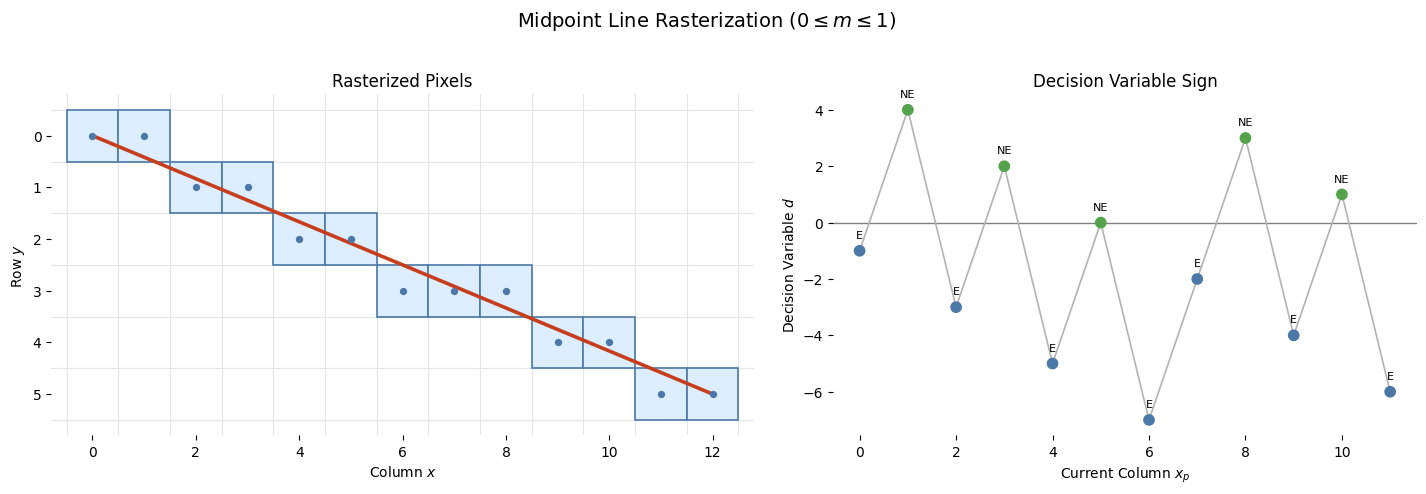

In [4]:
from matplotlib.patches import Rectangle


def f(x, y, x0, y0, x1, y1):
    return (y1 - y0) * (x - x0) - (x1 - x0) * (y - y0)


x0, y0, x1, y1 = 0, 0, 12, 5

xp, yp = x0, y0
pixels = [(xp, yp)]
steps = []

d = f(xp + 1, yp + 0.5, x0, y0, x1, y1)
steps.append((xp, d, "E" if d < 0 else "NE"))

while xp < x1:
    if d < 0:
        xp += 1
        d += (y1 - y0)
    else:
        xp += 1
        yp += 1
        d += (y1 - y0) - (x1 - x0)

    pixels.append((xp, yp))

    if xp < x1:
        steps.append((xp, d, "E" if d < 0 else "NE"))


fig, ax = plt.subplots(
    1, 2, figsize=(14.5, 4.8),
    gridspec_kw={"width_ratios": [1.25, 1]}
)

# left panel: rasterized pixels
for gx in range(-1, 14):
    ax[0].axvline(gx + 0.5, color="0.9", lw=0.8, zorder=0)
for gy in range(-1, 7):
    ax[0].axhline(gy + 0.5, color="0.9", lw=0.8, zorder=0)

for px, py in pixels:
    ax[0].add_patch(
        Rectangle(
            (px - 0.5, py - 0.5), 1, 1,
            facecolor="#dceeff", edgecolor="#4c78a8", lw=1.2, zorder=1
        )
    )

ax[0].plot([x0, x1], [y0, y1], color="#c73e1d", lw=2.6, zorder=3)
ax[0].scatter(
    [p[0] for p in pixels],
    [p[1] for p in pixels],
    s=18, color="#4c78a8", zorder=4
)

ax[0].set_xlim(-0.8, 12.8)
ax[0].set_ylim(-0.8, 5.8)
ax[0].invert_yaxis()
ax[0].set_aspect("equal")
ax[0].set_xticks(range(0, 13, 2))
ax[0].set_yticks(range(0, 6))
ax[0].set_xlabel(r"Column $x$")
ax[0].set_ylabel(r"Row $y$")
ax[0].set_title("Rasterized Pixels")

for spine in ax[0].spines.values():
    spine.set_visible(False)

# right panel: decision variable trace
tx = [s[0] for s in steps]
td = [s[1] for s in steps]
choices = [s[2] for s in steps]
colors = ["#4c78a8" if val < 0 else "#54a24b" for val in td]

ax[1].axhline(0, color="0.5", lw=1.0, zorder=0)
ax[1].plot(tx, td, color="0.7", lw=1.2, zorder=1)
ax[1].scatter(tx, td, s=55, c=colors, zorder=2)

for x, y, label in zip(tx, td, choices):
    ax[1].annotate(
        label, (x, y),
        textcoords="offset points", xytext=(0, 9),
        ha="center", fontsize=8
    )

ax[1].set_xlabel(r"Current Column $x_p$")
ax[1].set_ylabel(r"Decision Variable $d$")
ax[1].set_title("Decision Variable Sign")
for spine in ax[1].spines.values():
    spine.set_visible(False)

fig.suptitle(r"Midpoint Line Rasterization ($0 \leq m \leq 1$)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

The left panel runs the rule across a segment: the chosen pixels track the line as a staircase, each column an integer addition and a sign test. The right panel plots $d$, which crosses zero exactly when the pixel steps up a row.

### Incremental Line Drawing with a Symmetric Error Term

The midpoint derivation above assumes a single octant: the line advances to the right, its slope lies between zero and one, and each step chooses between $E$ and $NE$. A practical line rasterizer, however, must handle every direction and every slope. Rather than splitting the plane into octants and writing separate cases, the standard symmetric formulation uses one error term and one update loop for all lines.

Following Zingl, let

$$dx = |x_1 - x_0|, \qquad sx =
\begin{cases}
1, & x_0 < x_1,\\
-1, & x_0 \ge x_1,
\end{cases}$$

and

$$dy = -|y_1 - y_0|, \qquad sy =
\begin{cases}
1, & y_0 < y_1,\\
-1, & y_0 \ge y_1.
\end{cases}$$

The initial error term is then

$$err = dx + dy,$$

where $dy$ is negative by construction. At each iteration the algorithm emits the current pixel, forms $e_2 = 2\,err$, and tests whether the next step should advance in $x$, in $y$, or in both. The update rules are

$$\text{if } e_2 \ge dy,\quad err \leftarrow err + dy,\quad x \leftarrow x + sx,$$

$$\text{if } e_2 \le dx,\quad err \leftarrow err + dx,\quad y \leftarrow y + sy.$$

Because the two tests are independent, the same loop covers shallow, steep, horizontal, vertical, and diagonal lines. For a shallow line the $x$-update occurs almost every iteration and the $y$-update only when needed; for a steep line the roles reverse; for a diagonal line both updates occur together.

This form is equivalent to the midpoint construction, but written so that the arithmetic is symmetric in $x$ and $y$ and remains purely integer. Each accepted $x$-step contributes the $dy$ increment to the error term, each accepted $y$-step contributes the $dx$ increment, and the combined effect reproduces the same incremental decision process without separate octant-specific routines.

This is the structure used by the line kernel in `prism`. In `_accumulate_line`, the rasterizer carries an integer error term, updates it by addition alone, and chooses the next pixel through these symmetric tests before depositing coverage into the accumulation buffer.

In [5]:
from matplotlib.patches import Rectangle


def accumulate_line(accum, x0, y0, x1, y1, alpha):
    h, w = accum.shape
    ix0, iy0 = int(round(x0)), int(round(y0))
    ix1, iy1 = int(round(x1)), int(round(y1))

    dx = abs(ix1 - ix0)
    dy = abs(iy1 - iy0)
    sx = 1 if ix0 < ix1 else -1
    sy = 1 if iy0 < iy1 else -1
    err = dx - dy

    x, y = ix0, iy0
    while True:
        if 0 <= x < w and 0 <= y < h:
            accum[y, x] = min(accum[y, x] + alpha, 1.0)

        if x == ix1 and y == iy1:
            break

        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x += sx
        if e2 < dx:
            err += dx
            y += sy

    return accum


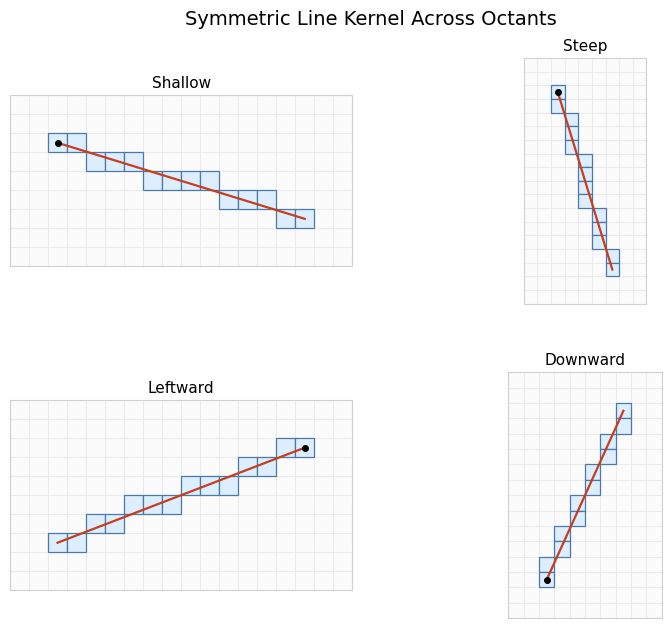

In [6]:
cases = [
    ((13, 4), "Shallow"),
    ((4, 13), "Steep"),
    ((-13, 5), "Leftward"),
    ((5, -11), "Downward"),
]

fig, ax = plt.subplots(2, 2, figsize=(8.2, 7.0))
ax = ax.ravel()

ox, oy = 16, 16
pad = 2

for panel, (endpoint, label) in zip(ax, cases):
    ex, ey = endpoint
    buf = np.zeros((32, 32), dtype="float32")
    accumulate_line(buf, ox, oy, ox + ex, oy + ey, 1.0)

    ys, xs = np.nonzero(buf)

    xmin = min(ox, ox + ex) - pad
    xmax = max(ox, ox + ex) + pad
    ymin = min(oy, oy + ey) - pad
    ymax = max(oy, oy + ey) + pad

    for gx in range(xmin, xmax + 1):
        panel.axvline(gx - 0.5, color="0.92", lw=0.8, zorder=0)
    for gy in range(ymin, ymax + 1):
        panel.axhline(gy - 0.5, color="0.92", lw=0.8, zorder=0)

    for px, py in zip(xs, ys):
        panel.add_patch(
            Rectangle(
                (px - 0.5, py - 0.5), 1, 1,
                facecolor="#dceeff",
                edgecolor="#4c78a8",
                lw=0.9,
                zorder=1
            )
        )

    panel.plot([ox, ox + ex], [oy, oy + ey], color="#c73e1d", lw=1.6, zorder=2)
    panel.scatter([ox], [oy], s=16, color="black", zorder=3)

    panel.set_title(label, fontsize=11, pad=6)
    panel.set_xlim(xmin - 0.5, xmax + 0.5)
    panel.set_ylim(ymax + 0.5, ymin - 0.5)
    panel.set_aspect("equal")
    panel.set_xticks([])
    panel.set_yticks([])

    panel.set_facecolor("#fbfbfb")
    for spine in panel.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("0.82")

fig.suptitle("Symmetric Line Kernel Across Octants", fontsize=14, y=0.97)

plt.subplots_adjust(left=0.06, right=0.97, top=0.90, bottom=0.10, wspace=0.18, hspace=0.28)
plt.show()

Four lines leave the same origin into different octants, and the single loop rasterizes each as a clean staircase. The sign terms $s_x$ and $s_y$ set the direction, and the two error tests decide which axis advances.

The kernel adds `alpha` to a coverage buffer and clamps at one, so overlapping lines accumulate. This is what the bristle deposit needs when many paths cross the same pixels.

## Brush and Stroke Path Construction  

### The Brush as a Bundle of Bristles

A brush stroke is the accumulated deposit of many bristles rather than a single rasterized line. In `prism`, a brush is a set of $n$ bristles, where bristle $i$ is defined by an offset $(\delta x_i, \delta y_i)$ from the brush center and attributes $(L_i, r_i, a_i, \rho_i, \eta_i)$ for length, radius, opacity, stiffness, and flex.

The offsets determine the brush footprint and thus its overall shape, while the per-bristle parameters introduce controlled variation within that footprint. `create_brush` samples these quantities from seeded random ranges and returns a `Brush` object that stores the resulting arrays, which the stroke routines then sweep together along a path.

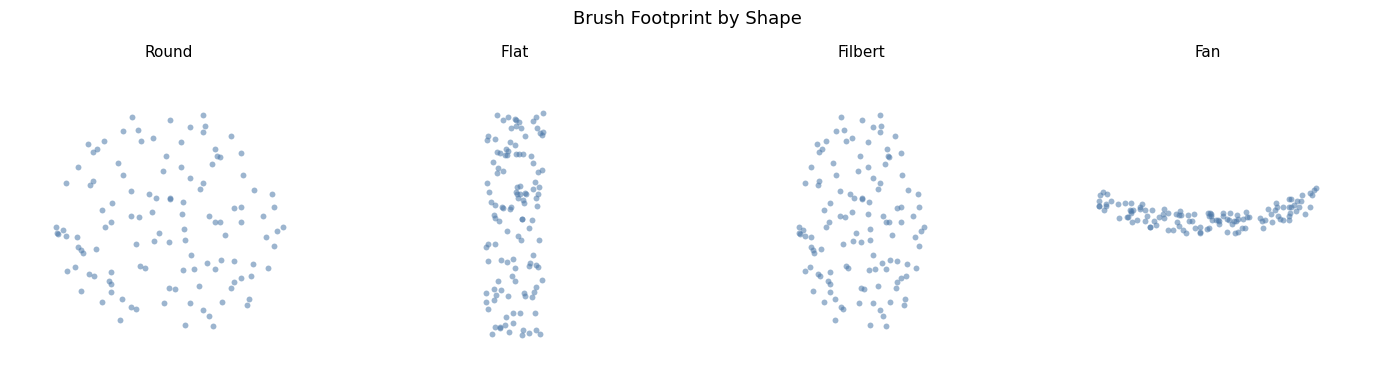

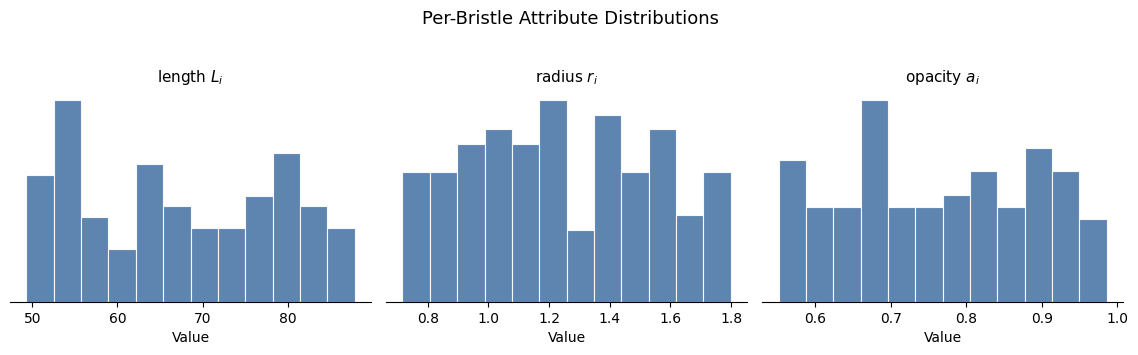

In [7]:
from prism.paint.brush import BrushShape, create_brush


# figure 1: brush footprint by shape
shapes: list[BrushShape] = ["round", "flat", "filbert", "fan"]
radius = 40.0
n_bristles = 120
seed = 7

fig, ax = plt.subplots(1, len(shapes), figsize=(14, 3.8), sharex=True, sharey=True)

for col, shape in zip(ax, shapes):
    brush = create_brush(radius=radius, n_bristles=n_bristles, shape=shape, seed=seed)
    xy = brush.xy

    col.scatter(
        xy[:, 0],
        xy[:, 1],
        s=18,
        color="#4c78a8",
        alpha=0.55,
        linewidths=0,
    )

    col.set_title(shape.title(), fontsize=11)
    col.set_aspect("equal")
    col.set_xlim(-55, 55)
    col.set_ylim(-55, 55)
    col.set_xticks([])
    col.set_yticks([])

    for spine in col.spines.values():
        spine.set_visible(False)

fig.suptitle("Brush Footprint by Shape", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


# figure 2: per-bristle attribute distributions
brush = create_brush(radius=radius, n_bristles=n_bristles, shape="filbert", seed=seed)

attrs = [
    (brush.L, r"length $L_i$"),
    (brush.r, r"radius $r_i$"),
    (brush.a, r"opacity $a_i$"),
]

fig, ax = plt.subplots(1, len(attrs), figsize=(11.5, 3.4))

for col, (vals, name) in zip(ax, attrs):
    bins = np.linspace(vals.min(), vals.max(), 13)

    col.hist(
        vals,
        bins=bins,
        color="#4c78a8",
        alpha=0.9,
        edgecolor="white",
        linewidth=0.8,
    )

    col.set_title(name, fontsize=11)
    col.set_xlabel("Value", fontsize=10)
    col.set_yticks([])

    for spine in ["top", "right", "left"]:
        col.spines[spine].set_visible(False)

fig.suptitle("Per-Bristle Attribute Distributions", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

### Stroke Geometry: Path, Width, Taper, and Orientation

A stroke is formed by sweeping a brush along a centerline. Let the path be the ordered points $p_0, p_1, \dots, p_n$; over segment $k$, the direction of travel is the unit tangent

$$
\mathbf{t}_k = \frac{p_k - p_{k-1}}{\lVert p_k - p_{k-1} \rVert}.
$$

This tangent governs the local stroke geometry. It sets the direction in which bristles trail, and it may also rotate the brush footprint so that a non-circular brush changes its presented width with the direction of motion.

Stroke width is determined by the footprint carried along the path. If bristle $i$ has offset $(\delta x_i, \delta y_i)$, then the set of offsets defines the cross-section swept by the brush center; a round footprint yields nearly constant width, whereas a flat footprint yields a broad or narrow mark depending on its orientation relative to $\mathbf{t}_k$.

Taper modulates the deposit along arclength. If $s$ denotes distance traveled along the path, the deposited weight is scaled by a taper function $w(s)$ that decreases toward the stroke end; in `prism`, this produces a gradual thinning rather than an abrupt cutoff.

Bristle curvature is controlled by the brush parameters. As the path turns, each bristle tip lags the center and reorients according to its stiffness $\rho_i$ and flex $\eta_i$, so stiff bristles remain close to their rest offsets while flexible bristles bend to follow the local direction of motion.

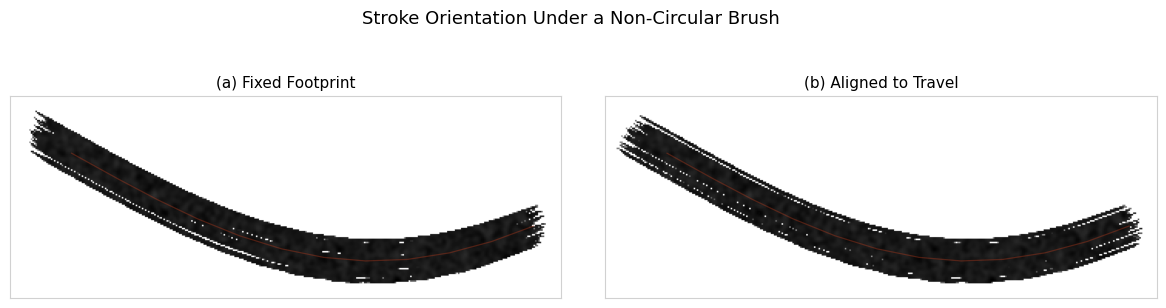

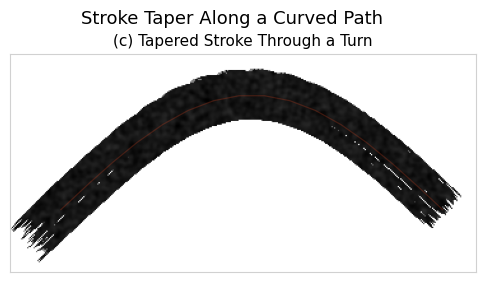

In [8]:
from prism.paint.brush import create_brush, rasterize_stroke, resample_path


shape_hw = (200, 380)

# figure 1: orientation comparison
ts = np.linspace(0, 1, 12)
path = np.column_stack([
    40 + 300 * ts,
    100 + 70 * np.sin(2.4 * ts),
]).astype("float32")
path = resample_path(path, step=1.5)

brush = create_brush(radius=14.0, n_bristles=64, shape="filbert", seed=7)

strokes = [
    rasterize_stroke(shape_hw, path, brush, render="line", rotate=False, seed=7),
    rasterize_stroke(shape_hw, path, brush, render="line", rotate=True, seed=7),
]
titles = ["(a) Fixed Footprint", "(b) Aligned to Travel"]

xmin = shape_hw[1]
xmax = 0
ymin = shape_hw[0]
ymax = 0

for stroke in strokes:
    x0, x1, y1, y0 = crop(stroke, pad=10)
    xmin = min(xmin, x0)
    xmax = max(xmax, x1)
    ymin = min(ymin, y0)
    ymax = max(ymax, y1)

fig, ax = plt.subplots(1, 2, figsize=(12.2, 3.9))

for col, stroke, title in zip(ax, strokes, titles):
    col.imshow(1.0 - stroke, cmap="gray", vmin=0, vmax=1)
    col.plot(path[:, 0], path[:, 1], color="#c73e1d", lw=0.9, alpha=0.35)
    col.set_xlim(xmin, xmax)
    col.set_ylim(ymax, ymin)
    col.set_title(title, fontsize=11, pad=6)
    style_panel(col, face="#fbfbfb")

fig.suptitle("Stroke Orientation Under a Non-Circular Brush", fontsize=13, y=0.98)
plt.subplots_adjust(left=0.04, right=0.98, top=0.86, bottom=0.14, wspace=0.08)
plt.show()


# figure 2: one stroke showing taper and turning
ts = np.linspace(0, 1, 16)
arc = np.column_stack([
    40 + 300 * ts,
    150 - 90 * np.sin(np.pi * ts),
]).astype("float32")
arc = resample_path(arc, step=1.5)

brush = create_brush(radius=18.0, n_bristles=80, shape="flat", seed=3)
stroke = rasterize_stroke(shape_hw, arc, brush, render="line", rotate=True, seed=3)

x0, x1, y1, y0 = crop(stroke, pad=12)

fig, ax = plt.subplots(figsize=(10.4, 3.2))
ax.imshow(1.0 - stroke, cmap="gray", vmin=0, vmax=1)
ax.plot(arc[:, 0], arc[:, 1], color="#c73e1d", lw=0.9, alpha=0.28)
ax.set_xlim(x0, x1)
ax.set_ylim(y1, y0)
ax.set_title("(c) Tapered Stroke Through a Turn", fontsize=11, pad=6)
style_panel(ax, face="#fbfbfb")

fig.suptitle("Stroke Taper Along a Curved Path", fontsize=13, y=0.98)
plt.subplots_adjust(left=0.03, right=0.99, top=0.84, bottom=0.16)
plt.show()

### Coverage Accumulation and Stroke Stamping

A stroke is the accumulated deposit of many bristles in a single coverage buffer. At each pixel, the buffer stores a value in $[0,1]$, and overlapping deposits combine additively with saturation:

$$c \leftarrow \min(c + a,\, 1).$$

This rule makes dense overlap converge quickly to full coverage, while isolated bristle contacts remain faint. The result is a stroke with a solid interior and a broken edge.

`prism` supports two deposition modes. In line mode, each bristle trail is rasterized as a path by `_accumulate_line`. In splat mode, the trail is sampled at intervals, and each sample stamps a disc through `_accumulate_disc`. Both modes use the same accumulation rule and differ only in the primitive they write.

Stamping constructs a stroke from overlapping dabs rather than a continuous filament. Spacing successive discs closely makes their overlap produce a continuous mark. Spacing them farther apart leaves the trail visibly discrete.

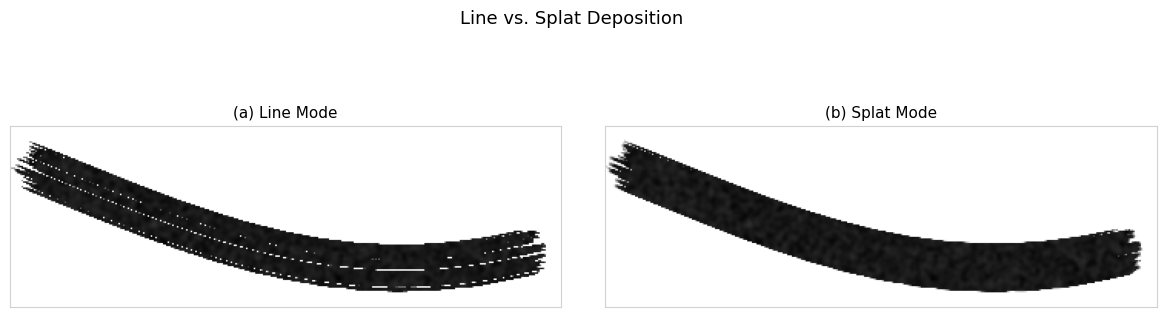

In [9]:
from prism.paint.brush import create_brush, rasterize_stroke, resample_path


shape_hw = (200, 380)

ts = np.linspace(0, 1, 14)
path = np.column_stack([40 + 300 * ts, 100 + 55 * np.sin(2.2 * ts)]).astype("float32")
path = resample_path(path, step=1.5)

brush = create_brush(radius=16.0, n_bristles=72, shape="filbert", seed=7)

line_stroke = rasterize_stroke(shape_hw, path, brush, render="line", rotate=True, seed=7)
splat_stroke = rasterize_stroke(shape_hw, path, brush, render="splat", rotate=True, seed=7)

x0 = x1 = y0 = y1 = None
for s in (line_stroke, splat_stroke):
    cx0, cx1, cy1, cy0 = crop(s, pad=10)
    x0 = cx0 if x0 is None else min(x0, cx0)
    x1 = cx1 if x1 is None else max(x1, cx1)
    y0 = cy0 if y0 is None else min(y0, cy0)
    y1 = cy1 if y1 is None else max(y1, cy1)

fig, ax = plt.subplots(1, 2, figsize=(12.2, 3.9))
for col, stroke, title in (
    (ax[0], line_stroke, "(a) Line Mode"),
    (ax[1], splat_stroke, "(b) Splat Mode"),
):
    col.imshow(1.0 - stroke, cmap="gray", vmin=0, vmax=1)
    col.set_xlim(x0, x1)
    col.set_ylim(y1, y0)
    col.set_title(title, fontsize=11, pad=6)
    style_panel(col, face="#fbfbfb")

fig.suptitle("Line vs. Splat Deposition", fontsize=13, y=0.99)
plt.subplots_adjust(left=0.04, right=0.98, top=0.86, bottom=0.06, wspace=0.08)
plt.show()

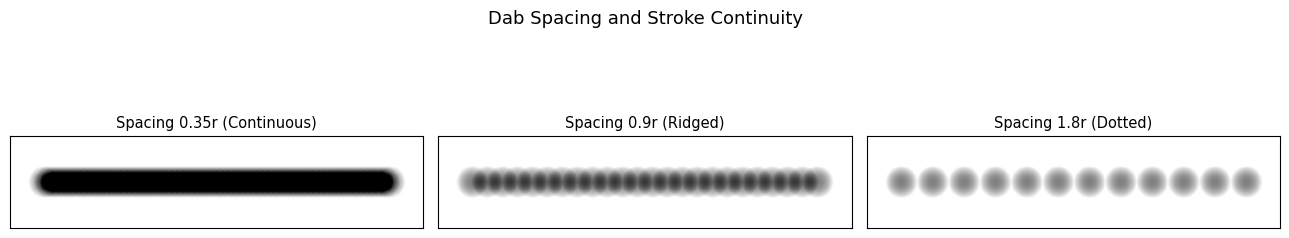

In [10]:
from prism.paint.brush import _accumulate_disc


def stamp_trail(buf, p0, p1, radius, alpha, spacing_frac):
    p0 = np.asarray(p0, dtype="float64")
    p1 = np.asarray(p1, dtype="float64")
    length = float(np.hypot(*(p1 - p0)))
    step = max(radius * spacing_frac, 0.5)
    n = max(int(length / step), 1)
    for k in range(n + 1):
        t = k / n
        x, y = (1 - t) * p0 + t * p1
        _accumulate_disc(buf, x, y, radius, alpha)
    return buf


fig, ax = plt.subplots(1, 3, figsize=(13, 3.0))
for col, frac, title in (
    (ax[0], 0.35, "Spacing 0.35r (Continuous)"),
    (ax[1], 0.9, "Spacing 0.9r (Ridged)"),
    (ax[2], 1.8, "Spacing 1.8r (Dotted)"),
):
    buf = np.zeros((80, 360), dtype="float32")
    stamp_trail(buf, (30, 40), (330, 40), radius=14.0, alpha=0.5, spacing_frac=frac)
    col.imshow(1.0 - buf, cmap="gray", vmin=0, vmax=1)
    col.set_title(title, fontsize=10.5)
    col.set_xticks([])
    col.set_yticks([])

fig.suptitle("Dab Spacing and Stroke Continuity", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Stroke Masks, Templates, and Caching

A full painting can need thousands of strokes, so rasterizing each one bristle by bristle is expensive. Many strokes differ only in length, width, or orientation, which makes them good candidates for reuse.

A stroke mask is the coverage buffer of a rendered stroke read as a grayscale image. Its values lie in $[0,1]$ — high in the interior, fading at the boundary — so it serves directly as an alpha field for compositing. In `prism`, `bristle_stroke_mask` rasterizes a straight bristle stroke and optionally smooths the edge with a Gaussian.

A template is a stroke mask rendered once at a reference size and reused by transformation. `render_bristle_template` builds this canonical mask as a horizontal, tapered stroke so later resizing and rotation stay smooth.

Caching discretizes the continuous stroke parameters into a finite set of variants. Length, width, and angle are quantized to a cache key; the mask is generated from the template on first request and retrieved after. This is the usual accuracy-performance tradeoff: finer quantization raises fidelity, coarser quantization stores fewer distinct masks.

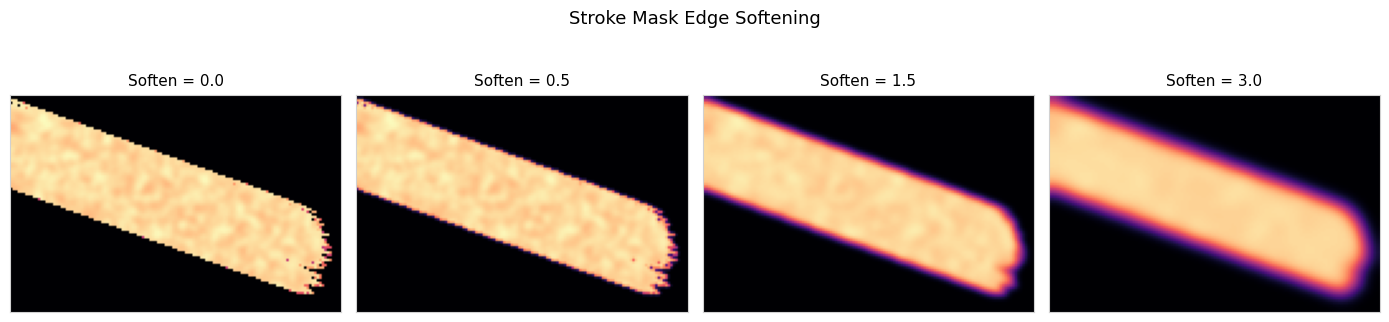

In [11]:
from prism.paint.mask import bristle_stroke_mask


softens = [0.0, 0.5, 1.5, 3.0]
fig, ax = plt.subplots(1, len(softens), figsize=(14, 3.4))

for col, soften in zip(ax, softens):
    mask, cy, cx = bristle_stroke_mask(length=110, width=34, angle_deg=20, seed=7, soften=soften)
    col.imshow(mask, cmap="magma", vmin=0, vmax=1)
    col.set_title(f"Soften = {soften}", fontsize=11)
    style_panel(col)

fig.suptitle("Stroke Mask Edge Softening", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

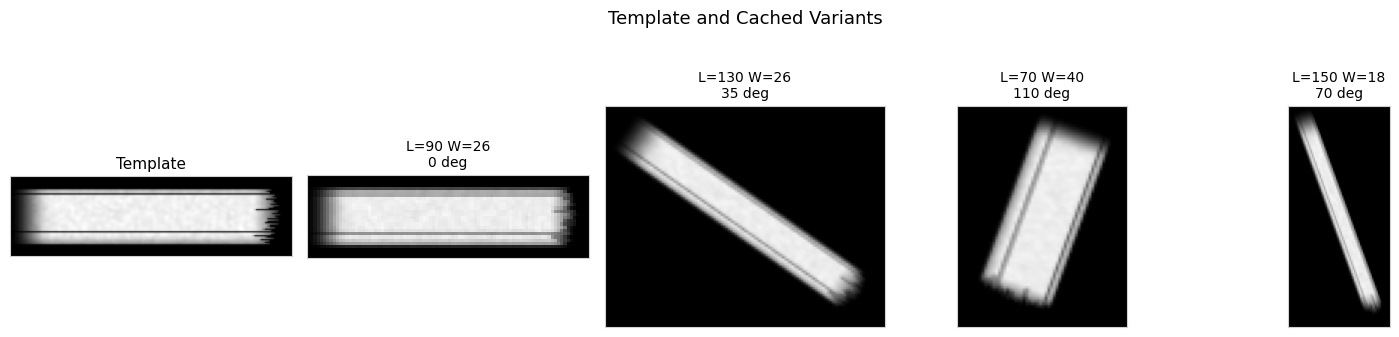

distinct cached entries: 4


In [12]:
from prism.paint.mask import render_bristle_template, TemplateCache


template = render_bristle_template(seed=7)
cache = TemplateCache(template)

requests = [(90, 26, 0.0), (130, 26, 35.0), (70, 40, 110.0), (150, 18, 70.0)]

fig, ax = plt.subplots(1, 5, figsize=(15, 3.2))

ax[0].imshow(template, cmap="gray")
ax[0].set_title("Template", fontsize=11)
style_panel(ax[0])

for col, (length, width, angle) in zip(ax[1:], requests):
    mask, cy, cx = cache.get(length, width, angle)
    col.imshow(mask, cmap="gray", vmin=0, vmax=1)
    col.set_title(f"L={length} W={width}\n{angle:.0f} deg", fontsize=10)
    style_panel(col)

fig.suptitle("Template and Cached Variants", fontsize=13, y=1.04)
fig.tight_layout()
plt.show()

print("distinct cached entries:", len(cache))

### Beyond the Line: Disc Rasterization and Bézier Paths

The line kernel draws one-pixel-wide marks. A brush needs more: round tips with soft edges, and curved bristle trails. Two primitives supply them — a disc gives a tip its width and falloff, a quadratic Bézier gives a trail its curve — and both reuse machinery already built. The disc is the implicit-circle form, the same implicit-function idea as the line; the Bézier is sampled into short segments, each drawn with the line kernel.

A disc is the set of pixels within radius $r$ of a center. The implicit form of a circle is

$$f(x, y) = (x - c_x)^2 + (y - c_y)^2 - r^2,$$

negative inside and positive outside, so a pixel belongs to the disc when $f \le 0$. A hard disc sets every interior pixel to full coverage, leaving a jagged rim. The brush instead weights each pixel by how far inside it sits, with a falloff that is one at the center and zero at the rim,

$$w(d) = 1 - \frac{d^2}{r^2}, \qquad d^2 = (x - c_x)^2 + (y - c_y)^2.$$

The deposit at a pixel is $a\,w$, the bristle's opacity scaled by this weight, so a tip is solid at its center and fades to nothing at its edge — stamped tips blend rather than stack as hard circles. In `prism`, `_accumulate_disc` walks the circle's bounding box, computes $d^2$ at each pixel center, skips pixels outside the radius, and accumulates $a\,w$ for the rest.

A bristle trail is a quadratic Bézier curve through a start $P_0$, a control point $P_1$, and an end $P_2$:

$$B(t) = (1 - t)^2 P_0 + 2(1 - t)t\,P_1 + t^2 P_2, \qquad t \in [0, 1].$$

It begins at $P_0$, ends at $P_2$, and bends toward $P_1$ without passing through it. The control point curves the trail: a straight bristle keeps $P_1$ on the line between its ends, a bent one pulls $P_1$ aside. Bristle bending sets $P_1$, which is how a trail curves as the brush turns.

The curve is not rasterized directly. It is sampled at a fixed number of $t$ values, and consecutive points are joined with the line kernel; a handful of segments approximates the curve closely enough that the joints vanish at brush scale. In `prism`, `_deposit_bristles` evaluates $B(t)$ at `samples + 1` values per bristle, strokes each segment with `_accumulate_line`, and applies the length taper as it goes.

Zingl extends the error-term method to rasterize a Bézier directly, choosing each pixel by the sign of the curve's implicit function — the same way the line kernel uses the sign of $f$ — with no sampling and no joints. `prism` samples instead: a bristle trail is short, a few line segments are indistinguishable from the exact curve at that size, and the line kernel is already in hand. The direct rasterizer is the more general tool; sampling is the one that fits here.

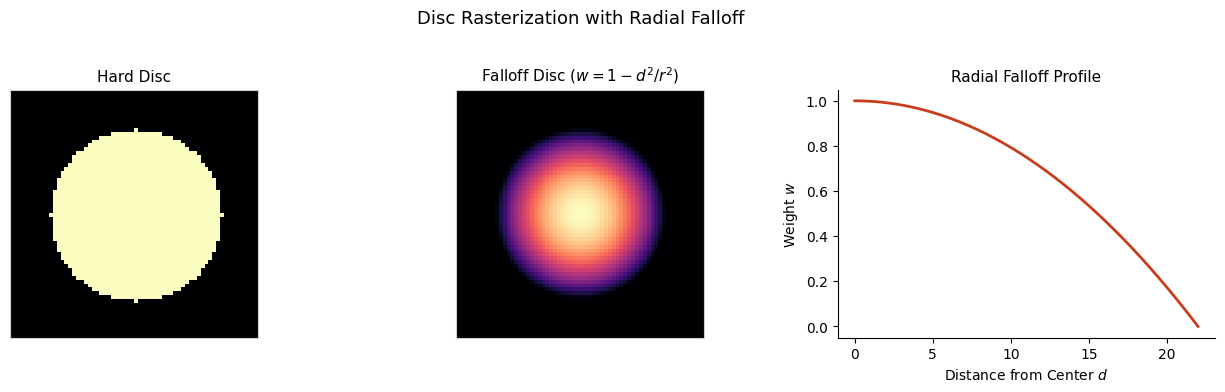

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))

hard = np.zeros((64, 64), dtype="float32")
yy, xx = np.mgrid[0:64, 0:64]
hard[((xx - 32) ** 2 + (yy - 32) ** 2) <= 22 ** 2] = 1.0
ax[0].imshow(hard, cmap="magma", vmin=0, vmax=1)
ax[0].set_title("Hard Disc", fontsize=11)
style_panel(ax[0])

soft = np.zeros((64, 64), dtype="float32")
_accumulate_disc(soft, 32.0, 32.0, 22.0, 1.0)
ax[1].imshow(soft, cmap="magma", vmin=0, vmax=1)
ax[1].set_title(r"Falloff Disc ($w = 1 - d^2/r^2$)", fontsize=11)
style_panel(ax[1])

r = 22.0
d = np.linspace(0, r, 200)
ax[2].plot(d, 1 - d ** 2 / r ** 2, color="#c73e1d", lw=2)
ax[2].set_xlabel(r"Distance from Center $d$")
ax[2].set_ylabel(r"Weight $w$")
ax[2].set_title("Radial Falloff Profile", fontsize=11)
for spine in ["top", "right"]:
    ax[2].spines[spine].set_visible(False)

fig.suptitle("Disc Rasterization with Radial Falloff", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

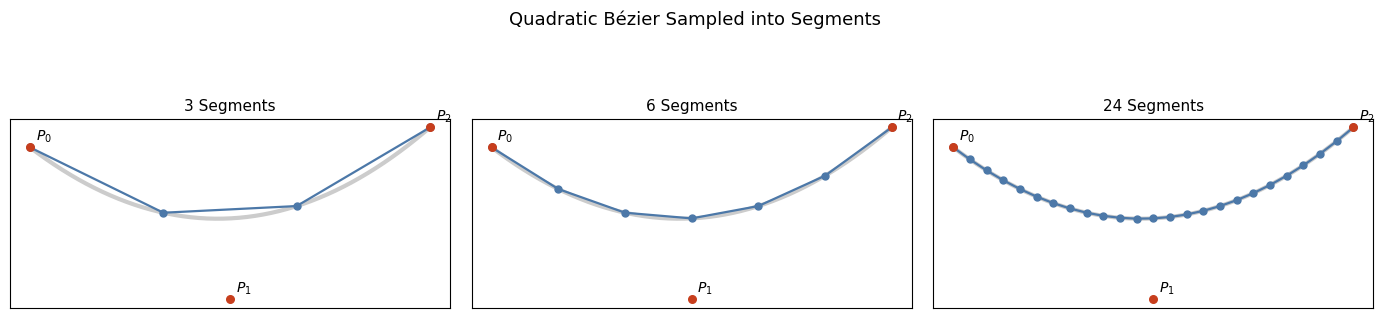

In [14]:

def bezier(p0, p1, p2, t):
    s = 1 - t
    return s * s * p0 + 2 * s * t * p1 + t * t * p2


P0 = np.array([10, 50])
P1 = np.array([60, 12])
P2 = np.array([110, 55])

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

for col, n in zip(ax, [3, 6, 24]):
    ts = np.linspace(0, 1, n + 1)
    pts = np.array([bezier(P0, P1, P2, t) for t in ts])

    smooth = np.array([bezier(P0, P1, P2, t) for t in np.linspace(0, 1, 200)])
    col.plot(smooth[:, 0], smooth[:, 1], color="0.8", lw=3, zorder=0)

    col.plot(pts[:, 0], pts[:, 1], color="#4c78a8", lw=1.6, marker="o", ms=5, zorder=2)
    for P, name in [(P0, "$P_0$"), (P1, "$P_1$"), (P2, "$P_2$")]:
        col.scatter(*P, color="#c73e1d", s=30, zorder=3)
        col.annotate(name, P, textcoords="offset points", xytext=(4, 5), fontsize=10)

    col.set_title(f"{n} Segments", fontsize=11)
    col.set_aspect("equal")
    col.set_xticks([])
    col.set_yticks([])

fig.suptitle("Quadratic Bézier Sampled into Segments", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### Anti-Aliasing: Coverage, Distance, and Perceived Edge Smoothness

The line kernel sets each pixel fully on or fully off. Along a slanted edge this produces a staircase — the jagged rim seen on the hard disc above. Anti-aliasing removes it by letting a pixel be partly covered: a pixel the edge crosses takes the fraction of its area the shape covers, and the row of graded pixels reads as a smooth line.

Coverage is the fraction of a pixel's area inside the shape — one fully inside, zero fully outside, intermediate where the boundary crosses. Assigning each pixel its coverage gives the edge a graded border one pixel wide instead of a hard step.

Exact area coverage is expensive, so the brush approximates it with distance. A pixel's coverage depends on how far its center sits from the edge: full well inside, zero well outside, ramping between across a band about one pixel wide. The disc falloff is one form of this — $1 - d^2/r^2$ rises from zero at the rim to one at the center, so the border is a distance ramp rather than a cliff. The stroke mask uses the same idea on a different shape: `soft_stroke_mask` measures each pixel's distance to the stroke's centerline segment and maps it through a coverage ramp.

The ramp works because of how the eye reads fine detail. Below the resolution limit, the visual system does not see individual pixels; it integrates light over a small region and perceives the local average. A hard edge forces every boundary pixel to black or white, and the averaging leaves a stair-stepped seam. A graded edge sets each boundary pixel to its coverage, so the local average follows the true edge position and the seam disappears. This is the same spatial averaging that lets stipple dots read as continuous tone.

Coverage also carries sub-pixel position. A hard edge can only place a boundary at a pixel border, so a slowly rotating line jumps from one staircase to the next. Graded coverage encodes where inside a pixel the edge falls, so the perceived edge can sit between pixel centers, and a line turning by a fraction of a degree shifts its coverage values smoothly.

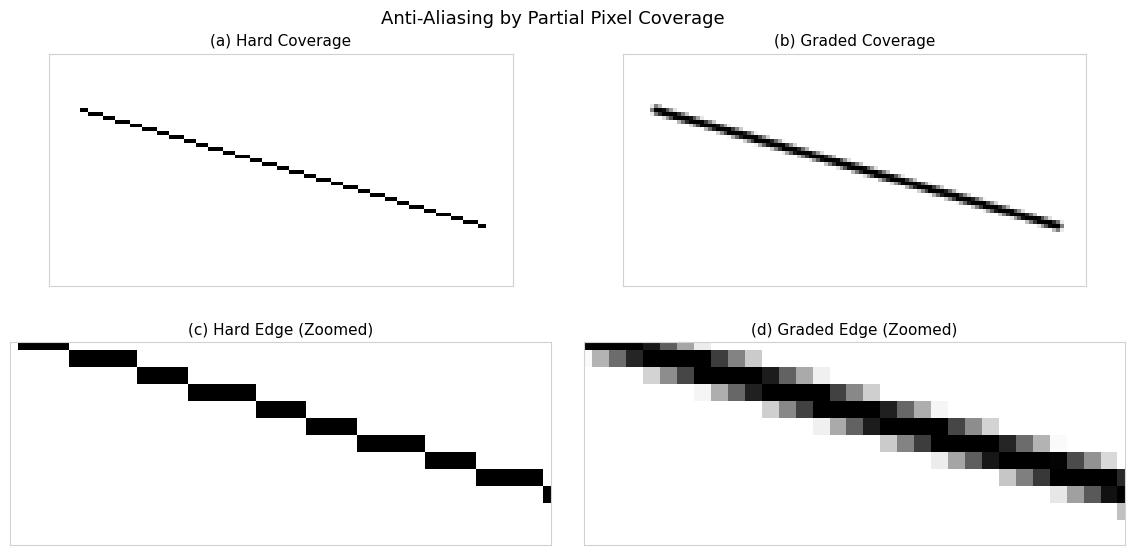

In [15]:
from prism.paint.brush import _accumulate_line


def aliased_line(shape, p0, p1):
    buf = np.zeros(shape, dtype="float32")
    _accumulate_line(buf, p0[0], p0[1], p1[0], p1[1], 1.0)
    return buf


def coverage_line(shape, p0, p1, half_width=1.0):
    h, w = shape
    yy, xx = np.mgrid[0:h, 0:w]

    p0 = np.array(p0, dtype="float64")
    p1 = np.array(p1, dtype="float64")
    seg = p1 - p0
    L2 = float(seg @ seg)

    t = ((xx - p0[0]) * seg[0] + (yy - p0[1]) * seg[1]) / L2
    t = np.clip(t, 0.0, 1.0)

    cx = p0[0] + t * seg[0]
    cy = p0[1] + t * seg[1]
    dist = np.hypot(xx - cx, yy - cy)

    return np.clip(half_width + 0.5 - dist, 0.0, 1.0).astype("float32")


shape = (60, 120)
p0, p1 = (8, 14), (112, 44)

hard = aliased_line(shape, p0, p1)
soft = coverage_line(shape, p0, p1)

zoom_xlim = (20, 52)
zoom_ylim = (30, 18)

fig, ax = plt.subplots(2, 2, figsize=(11.8, 6.4))

# top row: full comparison
ax[0, 0].imshow(hard, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
ax[0, 0].set_title("(a) Hard Coverage", fontsize=11, pad=6)
style_panel(ax[0, 0], face="#fbfbfb")

ax[0, 1].imshow(soft, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
ax[0, 1].set_title("(b) Graded Coverage", fontsize=11, pad=6)
style_panel(ax[0, 1], face="#fbfbfb")

# bottom row: zoomed comparison
ax[1, 0].imshow(hard, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
ax[1, 0].set_xlim(*zoom_xlim)
ax[1, 0].set_ylim(*zoom_ylim)
ax[1, 0].set_title("(c) Hard Edge (Zoomed)", fontsize=11, pad=6)
style_panel(ax[1, 0], face="#fbfbfb")

ax[1, 1].imshow(soft, cmap="gray_r", vmin=0, vmax=1, interpolation="nearest")
ax[1, 1].set_xlim(*zoom_xlim)
ax[1, 1].set_ylim(*zoom_ylim)
ax[1, 1].set_title("(d) Graded Edge (Zoomed)", fontsize=11, pad=6)
style_panel(ax[1, 1], face="#fbfbfb")

fig.suptitle("Anti-Aliasing by Partial Pixel Coverage", fontsize=13, y=0.97)

plt.subplots_adjust(
    left=0.04,
    right=0.985,
    top=0.90,
    bottom=0.11,
    wspace=0.06,
    hspace=0.18,
)
plt.show()

## Application: The `paint/brush.py` Rasterizer

The final step is to assemble these pieces into a complete stroke. In `paint/brush.py`, a caller constructs a brush with `create_brush`, supplies a path, and calls `rasterize_stroke`, which returns the stroke as a coverage buffer.

A stroke is determined by three inputs: the canvas size, the path, and the brush. Before sweeping the brush, `resample_path` redistributes the path points at uniform spacing so that deposits remain even along the centerline regardless of the original sampling. The output is a coverage buffer in $[0, 1]$ that can be composited directly onto the canvas.

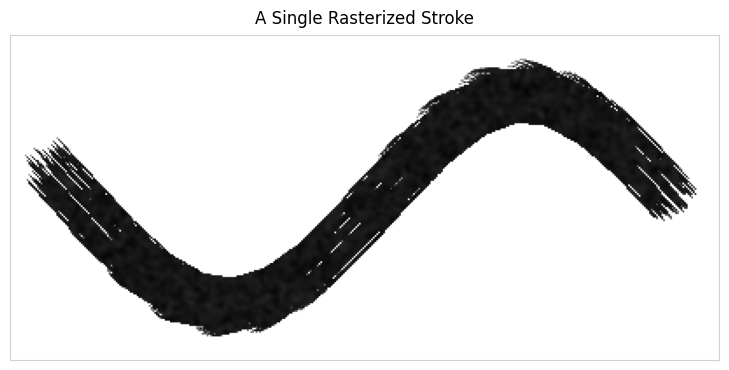

In [16]:
from prism.paint.brush import BrushShape, create_brush, rasterize_stroke, resample_path


shape_hw = (220, 420)

ts = np.linspace(0, 1, 16)
path = np.column_stack([40 + 340 * ts, 110 + 60 * np.sin(2.0 * np.pi * ts)]).astype("float32")
path = resample_path(path, step=1.5)

brush = create_brush(radius=16.0, n_bristles=72, shape="filbert", seed=7)
stroke = rasterize_stroke(shape_hw, path, brush, render="line", rotate=True, seed=7)

x0, x1, y1, y0 = crop(stroke, pad=14)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.imshow(1.0 - stroke, cmap="gray", vmin=0, vmax=1)
ax.set_xlim(x0, x1)
ax.set_ylim(y1, y0)
ax.set_title("A Single Rasterized Stroke", fontsize=12, pad=8)
style_panel(ax)
fig.tight_layout()
plt.show()

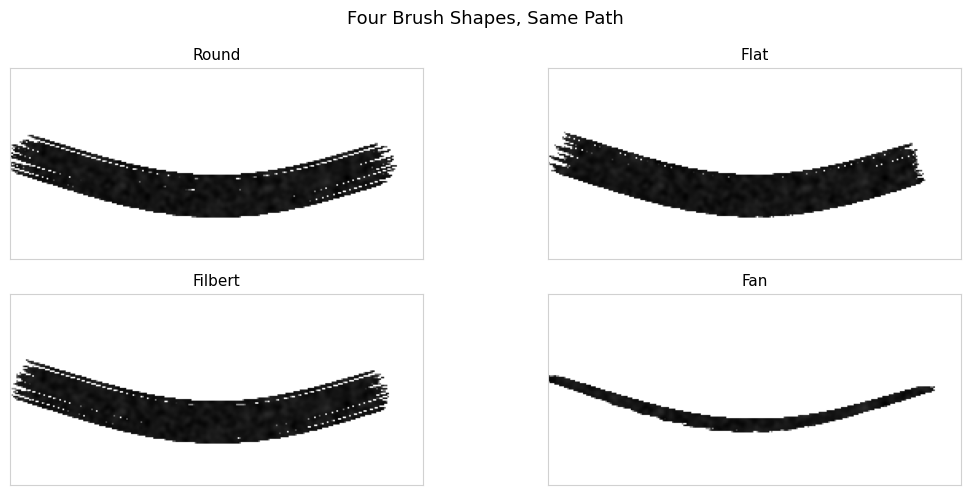

In [17]:
shapes: list[BrushShape] = ["round", "flat", "filbert", "fan"]

ts = np.linspace(0, 1, 14)
path = np.column_stack([30 + 200 * ts, 60 + 20 * np.sin(np.pi * ts)]).astype("float32")
path = resample_path(path, step=1.5)
panel_hw = (120, 260)

fig, ax = plt.subplots(2, 2, figsize=(11, 5))
for col, shape in zip(ax.ravel(), shapes):
    brush = create_brush(radius=13.0, n_bristles=64, shape=shape, seed=7)
    stroke = rasterize_stroke(panel_hw, path, brush, render="line", rotate=True, seed=7)
    col.imshow(1.0 - stroke, cmap="gray", vmin=0, vmax=1)
    col.set_title(shape.title(), fontsize=11)
    style_panel(col)

fig.suptitle("Four Brush Shapes, Same Path", fontsize=13, y=0.98)
fig.tight_layout()
plt.show()

The first figure shows a complete stroke produced from the high-level calls. `create_brush` constructs the bristle bundle, `resample_path` redistributes the path points at uniform spacing, and `rasterize_stroke` sweeps the brush to produce the coverage buffer. Within that sweep, the line kernel traces each bristle, the bristles reorient through the curve, the taper attenuates the ends, and the deposits accumulate into a single field.

The second figure holds the path fixed and varies only the brush shape. The round brush produces a nearly uniform band; the flat brush changes apparent width as its footprint rotates with the path; the filbert preserves that directional behavior but with softer ends; and the fan separates into visibly distinct strands. The comparison isolates the contribution of footprint geometry to stroke character.

The third figure holds the path and brush specification fixed and varies only the random seed. The seed changes the sampled per-bristle attributes and therefore the fine internal structure of the mark, but each stroke remains deterministic once the seed is set. Reusing the same seed reproduces the same stroke exactly, which makes higher-level painting procedures repeatable.

A stroke mask is the same rasterized mark prepared for later compositing. `bristle_stroke_mask` renders a straight stroke, softens its boundary, and returns both the coverage image and the center offset needed for placement. When many similar strokes are reused, `TemplateCache` amortizes the cost by storing a canonical template and serving transformed copies instead of rerasterizing each stroke from scratch.

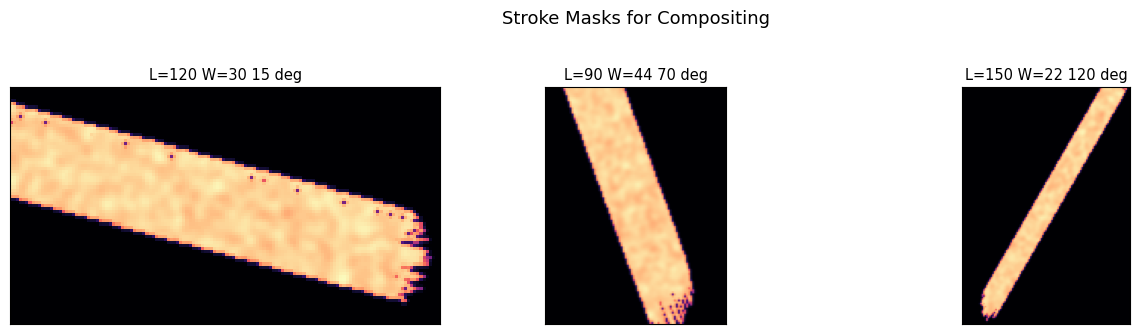

In [18]:
from prism.paint.mask import bristle_stroke_mask

fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
for col, (length, width, angle) in zip(ax, [(120, 30, 15), (90, 44, 70), (150, 22, 120)]):
    mask, cy, cx = bristle_stroke_mask(length=length, width=width, angle_deg=angle, seed=7, soften=0.5)
    col.imshow(mask, cmap="magma", vmin=0, vmax=1)
    col.set_title(f"L={length} W={width} {angle} deg", fontsize=10.5)
    col.set_xticks([])
    col.set_yticks([])

fig.suptitle("Stroke Masks for Compositing", fontsize=13, y=1.03)
fig.tight_layout()
plt.show()